# Permeation Readiness — Interactive Prediction

The pooled monitor is trained once on the conducting systems of this project
(gramicidin A, MthK, KcsA-E71A) and then frozen. It predicts one thing: whether
at least one ion completes a crossing in the window (t, t + τ].

It can be pointed at any protein that has a configuration and one `autodetect`
and one `events` run, not only the three it was trained on. The model is applied
by feature name, so an unseen system is scored by the same path as a training
system; the last cell lists what a new protein needs. On an unfamiliar family
the applicable quality is the transfer quality measured in
`../runs/monitor-generalisation-tau1000/`.

Three questions are answered below, all on the same trajectory:

1. what is measured at the pore at time t — no model, no horizon;
2. whether it will conduct within τ — the verdict for (t, t + τ], the mechanism
   behind it, and the same frame at other horizons;
3. how readiness runs over a stretch, against the crossings that happened.

Questions 1 and 2 use the same frame: the first reports the measurement there,
the second the model output for it.


In [1]:
PROTEIN = "gramicidin"    # system id from configs/ — or a path to the data folder
CONDITION = None          # None -> first condition of the system
REPLICA = None            # None -> first replica of the condition

TAU_PS = 1000.0           # prediction horizon: "a crossing completes within τ ps"
VARIANT = "physics_only"  # "physics_only" (recommended off-family) or "full"

TIME_PS = 100000.0            # the single moment for questions 1 and 2
RANGE_PS = (50000.0, 150000.0)  # the stretch for question 3
HORIZONS_PS = (500.0, 1000.0, 2000.0, 4000.0)  # horizon sweep shown in question 2

In [2]:
import warnings

warnings.filterwarnings("ignore")
import predict_lib as pl
from pcm2.runtime import run_dir

cfg = pl.resolve_config(PROTEIN)
print(f"system: {cfg['system.id']} | permeant: {cfg['system.permeant']} | "
      f"axis: {cfg['data.pore.axis']} | stride: {cfg['data.stride']}")
for c in cfg["data.conditions"]:
    print(f"  condition {c['id']} (direction {c.get('direction')}): "
          f"replicas {[r['id'] for r in c['replicas']]}")

# preflight: what this system already carries
root = run_dir(cfg)
for what, path in [("features table", root / "features" / "features.parquet"),
                   ("events (required)", root / "events" / "events.parquet"),
                   ("autodetect", root / "autodetect" / "report.json")]:
    print(f"  {what:20s}: {'present' if path.exists() else 'ABSENT'}")

system: gramicidin | permeant: K | axis: z | stride: 4
  condition 298K_2Msalt (direction 1): replicas ['01', '02', '03', '04', '05']
  condition 330K_1Msalt (direction 1): replicas ['01', '02', '03', '04', '05']
  features table      : present
  events (required)   : present
  autodetect          : present


In [3]:
bundle = pl.load_pooled_model(tau_ps=TAU_PS, variant=VARIANT)
trained = sorted({u.split(":")[0] for u in bundle["trained_on"]})
print(f"pooled model | τ = {bundle['tau_ps']:.0f} ps | {bundle['variant']} | "
      f"{len(bundle['columns'])} feature columns | READY threshold "
      f"{bundle['threshold']:.3f}")
print(f"trained on {len(bundle['trained_on'])} trajectory units of "
      f"{len(trained)} proteins ({', '.join(trained)}); "
      f"{bundle['train_rows']} rows, {bundle['train_positives']} positive "
      f"({bundle['base_rate']:.1%})")
if cfg["system.id"] not in trained:
    print(f"NOTE: {cfg['system.id']} is not in the training pool — this is a "
          f"zero-shot application.")

pooled model | τ = 1000 ps | physics_only | 79 feature columns | READY threshold 0.225
trained on 15 trajectory units of 3 proteins (gramicidin, kcsa, mthk); 26672 rows, 3243 positive (12.2%)


## 1. Measured pore state at t

In [4]:
# QUESTION 1 — measured pore state at t: no model, no horizon.
row, cond, source, offset = pl.row_at(cfg, CONDITION, REPLICA, TIME_PS)
one = row.iloc[0]
print(f"rows from: {source}")
if offset > 0:
    print(f"(nearest measured frame is {offset:.0f} ps from the requested time)")
print(pl.snapshot_text(one, {}))

rows from: computed table
state at t = 100000 ps (100.0 ns), 298K_2Msalt/01
  pore geometry:
    constriction radius: 0.768 Å
    constriction position on the axis: -11 Å
    lining hydrophobicity at the constriction: 0.207 WW scale
  hydration:
    water molecules in the pore: 8
    wet fraction of the recent window: 0.385
    water wire continuous (1 = yes): 0
    largest gap in the water wire: 4.69 Å
  ions:
    permeant ions in the pore: 1
    innermost ion position on the axis: 11.1 Å
    innermost ion desolvation: 0.571
    permeant ions at the entry mouth: 0
    nearest ion distance to the entry: 14 Å
    time since the last crossing: 2.12e+04 ps
  published criterion:
    Rao-2019 dewetting energy (>= 2.6 = dewetted): 23.4 kJ/mol


## 2. Verdict for the horizon τ

In [5]:
# QUESTION 2 — the model's verdict for (t, t+τ], the mechanism behind it,
# and the same frame at other horizons.
pred = pl.predict_rows(bundle, row)
reasons = pl.explain_rows(bundle, row, top_k=3)
print(pl.verdict_text(pred.iloc[0], reasons[0], TAU_PS))

cached = set(pl.cached_horizons(VARIANT))
print("\nthe same frame at the other cached horizons:")
for tau in HORIZONS_PS:
    if tau not in cached and tau != TAU_PS:
        print(f"  τ = {tau:6.0f} ps: not cached — skipped "
              f"(training it would refit the pooled model)")
        continue
    bt = pl.load_pooled_model(tau_ps=tau, variant=VARIANT)
    pt = pl.predict_rows(bt, row)
    state = "READY" if bool(pt["ready"].iloc[0]) else "NOT READY"
    print(f"  τ = {tau:6.0f} ps: P = {pt['p_ready'].iloc[0]:.3f} "
          f"(threshold {bt['threshold']:.3f}) -> {state}")

t = 100000 ps | horizon τ = 1000 ps | P(crossing within τ) = 0.022 → NOT READY
  1. constriction dehydration — weight 57% (driver: flu_r_constr_var_win = 0.0908)
  2. pathway/lining rearrangement — weight 19% (driver: geo_bin7_nsearch = 2)
  3. permeant delivery — weight 17% (driver: dlv_t_since_cross_ps = 2.12e+04)

the same frame at the other cached horizons:
  τ =    500 ps: P = 0.016 (threshold 0.170) -> NOT READY
  τ =   1000 ps: P = 0.022 (threshold 0.225) -> NOT READY
  τ =   2000 ps: P = 0.039 (threshold 0.290) -> NOT READY
  τ =   4000 ps: P = 0.115 (threshold 0.329) -> NOT READY


## 3. Readiness over a stretch

625 frames in [50000, 150000] ps — computed table
P(ready): median 0.024, IQR 0.008-0.065, max 0.509; READY on 31/625 frames (5.0% of the stretch)
5 crossings completed in this stretch


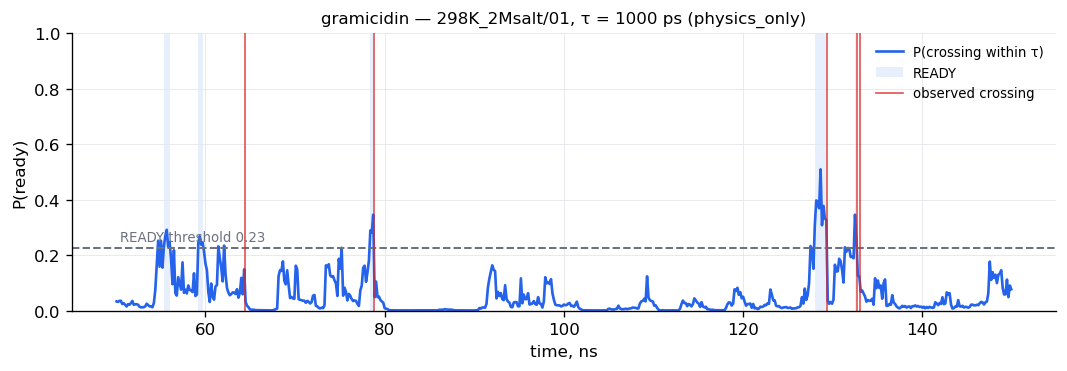

In [6]:
# QUESTION 3 — readiness over a stretch, against the observed crossings.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rows, cond, source = pl.query_rows(cfg, CONDITION, REPLICA, *RANGE_PS)
pred_r = pl.predict_rows(bundle, rows)
p = pred_r["p_ready"]
q1, q3 = p.quantile(0.25), p.quantile(0.75)
print(f"{len(rows)} frames in [{RANGE_PS[0]:.0f}, {RANGE_PS[1]:.0f}] ps — {source}")
print(f"P(ready): median {p.median():.3f}, IQR {q1:.3f}-{q3:.3f}, max {p.max():.3f}; "
      f"READY on {int(pred_r['ready'].sum())}/{len(pred_r)} frames "
      f"({pred_r['ready'].mean():.1%} of the stretch)")

t_ns = pred_r["time_ps"] / 1000.0
fig, ax = plt.subplots(figsize=(9, 3.2), dpi=120)
ax.plot(t_ns, p, color="#2563eb", lw=1.6, label="P(crossing within τ)")
ax.axhline(bundle["threshold"], color="#6b7280", lw=1.2, ls="--")
ax.annotate(f"READY threshold {bundle['threshold']:.2f}",
            xy=(t_ns.iloc[0], bundle["threshold"]), xytext=(2, 4),
            textcoords="offset points", fontsize=8, color="#6b7280")
ax.fill_between(t_ns, 0, 1, where=pred_r["ready"], color="#2563eb",
                alpha=0.10, linewidth=0, label="READY")

ev_path = run_dir(cfg) / "events" / "events.parquet"
if ev_path.exists():
    ev = pd.read_parquet(ev_path)
    ev = ev[(ev["condition"] == cond["id"])
            & (ev["replica"] == rows["replica"].iloc[0])]
    tx = ev["t_exit_ps"].to_numpy() / 1000.0
    tx = tx[(tx >= t_ns.iloc[0]) & (tx <= t_ns.iloc[-1])]
    for k, t in enumerate(tx):
        ax.axvline(t, color="#dc2626", lw=1.0, alpha=0.8,
                   label="observed crossing" if k == 0 else None)
    print(f"{len(tx)} crossings completed in this stretch")

ax.set_xlabel("time, ns")
ax.set_ylabel("P(ready)")
ax.set_ylim(0, 1)
ax.set_title(f"{cfg['system.id']} — {cond['id']}/{rows['replica'].iloc[0]}, "
             f"τ = {TAU_PS:.0f} ps ({bundle['variant']})", fontsize=10)
ax.grid(color="#e5e7eb", lw=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Applying the monitor to a new protein

The prediction path is generic: features are measured, the frozen pooled model
is applied by column name. What a new system needs, once:

1. `configs/<id>.yaml` — assembled by `python tools/init_configs.py` (it needs
   `system.id`, `data.data_root`, the conditions with their replica files and
   lineages, and the horizon keys).
2. `python -m pcm2.run autodetect --config configs/<id>.yaml` — fills the atom
   selections, the pore axis and extent, the coordination cutoff and the
   architecture profile. Without it the feature measurement cannot start.
3. `python -m pcm2.run events --config configs/<id>.yaml` — required, because
   the delivery descriptors are built from detected crossings.
4. The `features` step is optional: with it rows are read from the table, without
   it they are measured from the trajectory on demand.

Labels are never needed for the target system. The training pool is fixed: the
pooled model is trained on the three conducting systems only, and a new protein
is scored as a target without joining the pool.


## Notes and limits

τ defines the label: a crossing completes within the next τ ps. A useful
horizon sits below the typical interval between crossings and at or above the
transit time; for the training systems that is 1000–2000 ps (gramicidin ~8.3 ns
between crossings with a 0.8–1.8 ns transit, MthK ~2.4 ns, KcsA-E71A ~14 ns).
On a new protein, measure both from its own events before choosing. Cached
horizons load from `runs/pooled-predict/`; any other value refits the pooled
model once on the five configured systems, which is why the sweep above skips
uncached values.

Dynamics, fluctuation and persistence features are windowed backward, so a query
reads one `features.window_ps` stretch before the requested time and never
anything after it.

When rows are measured from the trajectory rather than read from a table, two
run-length ages (`dyn_wet_state_age_ps`, `dyn_occ_change_age_ps`) restart at the
window edge and are capped by the window length; every other model column
reproduces the pipeline tables exactly.

On a protein family absent from training, accuracy is the transfer accuracy of
the generalisation experiments, not in-system accuracy. `physics_only` is the
safer variant there: it drops the columns whose ranges do not overlap between
systems.

The pooled model is trained once per (τ, variant) on all conducting-system rows
(seed 20260816) and cached under `runs/pooled-predict/`; delete the cache or
pass `refresh=True` to retrain.
